# Visualize Instant-GI Probability Fields (`gt_pf.npy`)

This notebook visualizes the per-image probability fields stored next to Instant-GI 2D Gaussian exports:

```
<scene_gs_root>/<frame>/<init_method>/gt_pf.npy
```

It supports:
- heatmaps (linear + log)
- histogram + summary stats
- optional overlay on the corresponding RGB image
- sampling points according to the probability field


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Sequence, Tuple

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


def find_gt_pf_files(root: Path, limit: int = 5000) -> list[Path]:
    files = []
    for p in root.rglob("gt_pf.npy"):
        files.append(p)
        if len(files) >= limit:
            break
    return sorted(files)


def load_pf(path: Path) -> np.ndarray:
    pf = np.load(str(path)).astype(np.float32)
    if pf.ndim == 3 and pf.shape[0] == 1:
        pf = pf[0]
    if pf.ndim != 2:
        raise ValueError(f"Expected HxW pf, got shape {pf.shape} for {path}")
    pf = np.nan_to_num(pf, nan=0.0, posinf=0.0, neginf=0.0)
    pf = np.clip(pf, 0.0, None)
    return pf


def pf_stats(pf: np.ndarray) -> dict:
    s = float(pf.sum())
    nz = pf > 0
    return {
        "shape": pf.shape,
        "dtype": str(pf.dtype),
        "min": float(pf.min()),
        "max": float(pf.max()),
        "sum": s,
        "nonzero_frac": float(nz.mean()),
        "nonzero_mean": float(pf[nz].mean()) if nz.any() else 0.0,
    }


def normalize_pf_for_sampling(pf: np.ndarray) -> np.ndarray:
    w = pf.reshape(-1).astype(np.float64)
    total = float(w.sum())
    if total <= 0:
        w = np.ones_like(w)
        total = float(w.sum())
    return (w / total).astype(np.float64)


def load_optional_rgb(path: Path) -> Optional[np.ndarray]:
    if not path.exists():
        return None
    try:
        return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)
    except Exception:
        return None


def try_load_matching_image(
    stem: str, image_dir: Optional[Path]
) -> Optional[np.ndarray]:
    if image_dir is None:
        return None
    for ext in (".png", ".jpg", ".jpeg", ".PNG", ".JPG", ".JPEG"):
        p = image_dir / f"{stem}{ext}"
        if p.exists():
            return np.array(Image.open(p).convert("RGB"), dtype=np.uint8)
    # fallback: any file matching the stem
    matches = list(image_dir.glob(stem + ".*"))
    if matches:
        return np.array(Image.open(matches[0]).convert("RGB"), dtype=np.uint8)
    return None


def sample_points_from_pf(pf: np.ndarray, n: int, rng: np.random.Generator) -> Tuple[np.ndarray, np.ndarray]:
    h, w = pf.shape
    probs = normalize_pf_for_sampling(pf)
    idx = rng.choice(h * w, size=n, replace=True, p=probs)
    xs = idx % w
    ys = idx // w
    return xs.astype(np.int32), ys.astype(np.int32)


In [ ]:
# --- Config ---

# Root to search for gt_pf.npy files.
# Examples:
#   Path("gsplat/examples/data/360_v2_gs")
#   Path("data/garden_d4/output/garden_d4")
PF_ROOT = Path(r"C:\Users\Eric\Projects\2dgs\gsplat\examples\data\360_v2_gs\garden_d8\DSC08074\net")

# Optional: directory containing the corresponding RGB images for overlay.
# Example for mipnerf360 bicycle with factor=8:
#   Path("gsplat/examples/data/360_v2/bicycle/images_8_png")
IMAGE_DIR: Optional[Path] = None

# Choose which file to visualize after listing.
INDEX = 0

# Number of points to sample for the scatter visualization.
N_SAMPLES = 4000
SEED = 0


In [6]:
pf_files = find_gt_pf_files(PF_ROOT)
print(f"Found {len(pf_files)} gt_pf.npy files under {PF_ROOT}")
pf_files[:10]


Found 1 gt_pf.npy files under C:\Users\Eric\Projects\2dgs\gsplat\examples\data\360_v2_gs\garden_d8\DSC07956\net


[WindowsPath('C:/Users/Eric/Projects/2dgs/gsplat/examples/data/360_v2_gs/garden_d8/DSC07956/net/gt_pf.npy')]

In [7]:
if not pf_files:
    raise RuntimeError(f"No gt_pf.npy files found under {PF_ROOT}")

pf_path = pf_files[INDEX]
stem = pf_path.parent.parent.name  # <frame>/<init_method>/gt_pf.npy
pf = load_pf(pf_path)

# Preferred visualization images live alongside gt_pf.npy
pf_dir = pf_path.parent
render_img = load_optional_rgb(pf_dir / "render.png")
gt_img = load_optional_rgb(pf_dir / "gt.png")

# Fallback: load by filename stem from a separate image directory
img = try_load_matching_image(stem, IMAGE_DIR)

print("pf_path:", pf_path)
print("stem:", stem)
print("stats:", pf_stats(pf))
if gt_img is not None:
    print("gt.png:", gt_img.shape, gt_img.dtype)
if render_img is not None:
    print("render.png:", render_img.shape, render_img.dtype)
if img is not None and gt_img is None and render_img is None:
    print("fallback image:", img.shape, img.dtype)


pf_path: C:\Users\Eric\Projects\2dgs\gsplat\examples\data\360_v2_gs\garden_d8\DSC07956\net\gt_pf.npy
stem: DSC07956
stats: {'shape': (420, 648), 'dtype': 'float32', 'min': 0.0, 'max': 1.0, 'sum': 136201.8125, 'nonzero_frac': 0.9925999412110523, 'nonzero_mean': 0.504178524017334}
gt.png: (420, 648, 3) uint8
render.png: (420, 648, 3) uint8


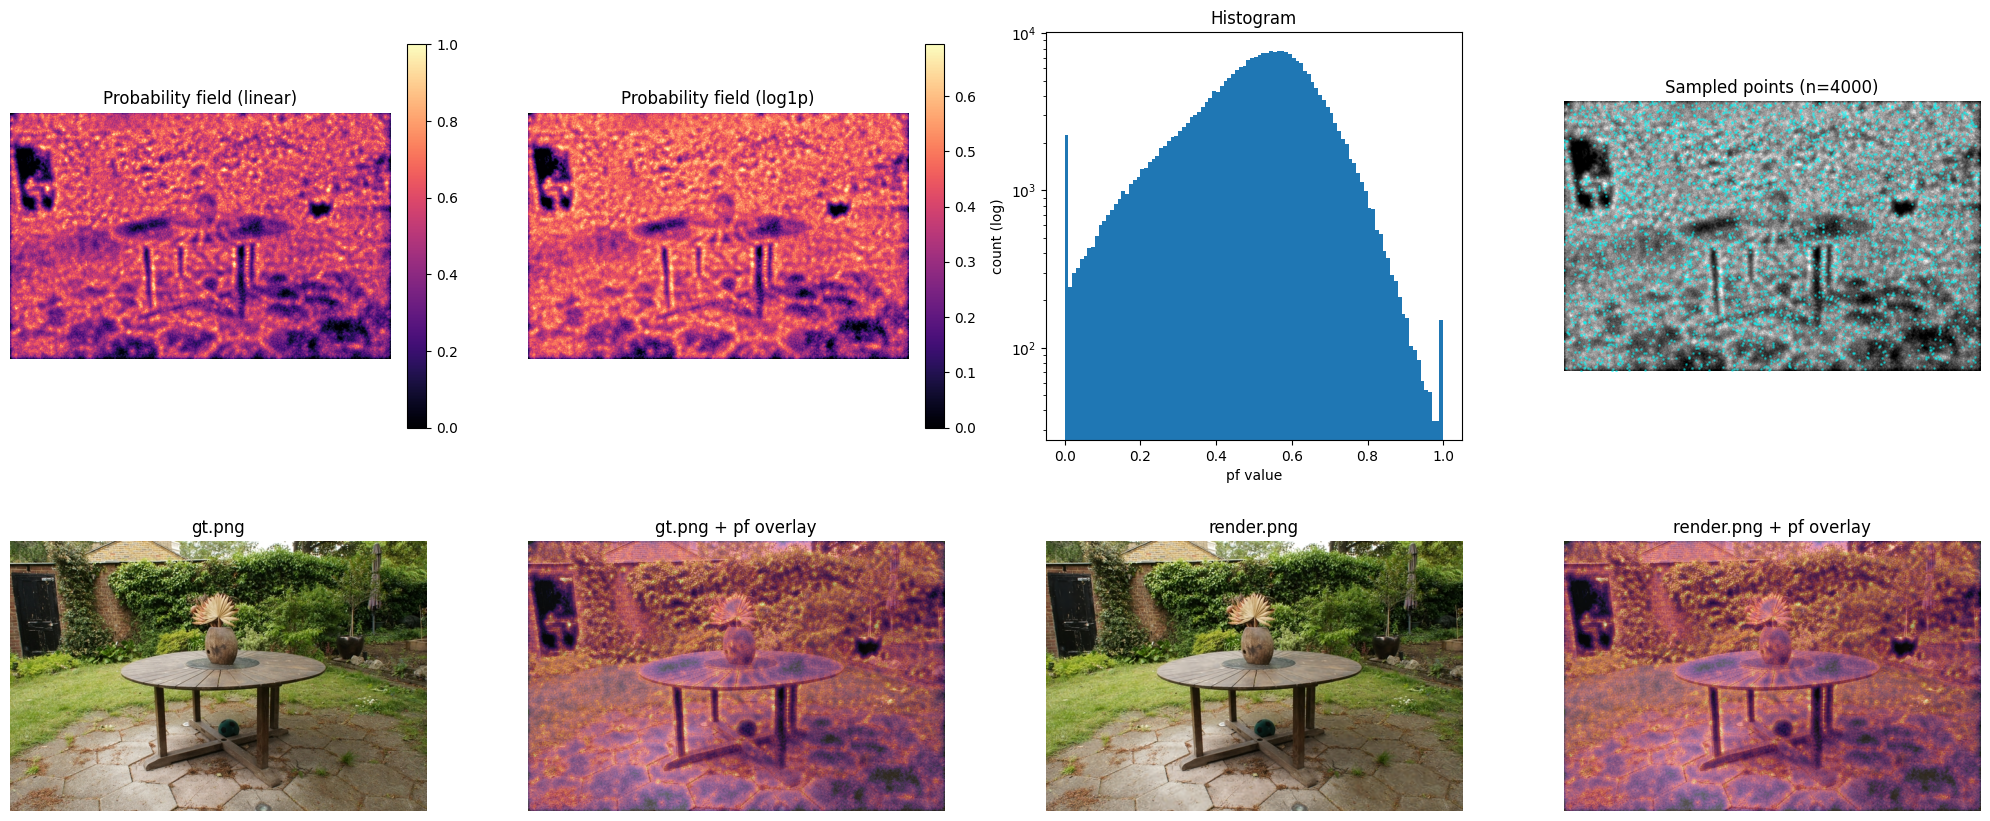

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

ax = axes[0, 0]
ax.set_title("Probability field (linear)")
im0 = ax.imshow(pf, cmap="magma")
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
ax.axis("off")

ax = axes[0, 1]
ax.set_title("Probability field (log1p)")
im1 = ax.imshow(np.log1p(pf), cmap="magma")
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
ax.axis("off")

ax = axes[0, 2]
ax.set_title("Histogram")
ax.hist(pf.reshape(-1), bins=100, log=True)
ax.set_xlabel("pf value")
ax.set_ylabel("count (log)")

rng = np.random.default_rng(SEED)
xs, ys = sample_points_from_pf(pf, N_SAMPLES, rng)

ax = axes[0, 3]
ax.set_title(f"Sampled points (n={N_SAMPLES})")
ax.imshow(pf, cmap="gray")
ax.scatter(xs, ys, s=1, c="cyan", alpha=0.4)
ax.axis("off")

pf_norm = pf / (pf.max() + 1e-8)

ax = axes[1, 0]
ax.set_title("gt.png")
if gt_img is None:
    ax.text(0.5, 0.5, "Missing gt.png", ha="center", va="center")
    ax.axis("off")
else:
    ax.imshow(gt_img)
    ax.axis("off")

ax = axes[1, 1]
ax.set_title("gt.png + pf overlay")
if gt_img is None:
    ax.text(0.5, 0.5, "Missing gt.png", ha="center", va="center")
    ax.axis("off")
else:
    ax.imshow(gt_img)
    ax.imshow(pf_norm, cmap="magma", alpha=0.55)
    ax.axis("off")

ax = axes[1, 2]
ax.set_title("render.png")
if render_img is None:
    ax.text(0.5, 0.5, "Missing render.png", ha="center", va="center")
    ax.axis("off")
else:
    ax.imshow(render_img)
    ax.axis("off")

ax = axes[1, 3]
ax.set_title("render.png + pf overlay")
if render_img is None:
    ax.text(0.5, 0.5, "Missing render.png", ha="center", va="center")
    ax.axis("off")
else:
    ax.imshow(render_img)
    ax.imshow(pf_norm, cmap="magma", alpha=0.55)
    ax.axis("off")

plt.tight_layout()
plt.show()
